# Corporate Actions Processing Engine  
## Portfolio Impact, Cost-Basis Validation, Exception Management & Audit Trail

Corporate actions are one of the most operationally sensitive parts of financial markets.

When a company announces a stock split, dividend, spin-off, merger, or other event, every affected client account must be updated correctly. A small error in quantity, cash, eligibility, or cost basis can flow directly into reporting, tax records, client statements, and downstream reconciliation.

This notebook builds a simplified but realistic **Corporate Actions / Asset Services processing engine** in Python.

The project simulates how a financial operations team processes a daily queue of corporate actions against a portfolio, while maintaining:

- position accuracy
- cost-basis conservation
- cash ledger updates
- auditability
- exception management
- end-of-cycle supervisor reporting

---

## Core question

> Can we process a corporate actions feed automatically while catching bad data before it corrupts the portfolio?

---

## What the engine does

The notebook starts with a sample portfolio and a queue of corporate actions.

It then:

1. validates each incoming action  
2. rejects invalid events into an exception queue  
3. applies valid events to the portfolio  
4. updates shares, average cost, cost basis, and cash  
5. records every successful action in an audit log  
6. checks whether value was preserved where expected  
7. reconciles the final portfolio against the starting portfolio  
8. produces before/after visuals and a supervisor-style summary report  

---

## Corporate action types covered

This version covers:

| Corporate Action | Portfolio Impact |
|---|---|
| Stock split | Quantity changes, average cost adjusts, total cost basis is preserved |
| Cash dividend | Cash balance increases, share quantity is unchanged |
| Spin-off | New security is created, cost basis is allocated between parent and child |
| Invalid / broken actions | Sent to exception queue for manual review |

---

## Why this matters

In real Asset Services teams, the goal is not just to process events.

The goal is to process the right events, for the right accounts, with the right economic impact, and to flag anything suspicious before it reaches client reporting.

That is why this project focuses on three professional controls:

1. **Eligibility checks**  
   Does the portfolio actually hold the affected security?

2. **Economic validation**  
   Did the event preserve value where it should?

3. **Auditability**  
   Can a reviewer trace exactly what changed, why it changed, and what was rejected?

---

## Project output

By the end of the notebook, the engine produces:

- updated portfolio holdings
- cash ledger
- audit log
- exception queue
- reconciliation table
- before/after charts
- processing KPIs
- supervisor summary report
- exportable files for GitHub / reporting

---

**Disclaimer:** This is an educational simulation. It is designed to demonstrate corporate actions logic, portfolio accounting controls, and exception handling.

# 1. Setup and Project Configuration

We start by importing the core Python libraries and defining a few project-level settings.

The notebook uses only standard data-analysis tools:

- `pandas` for portfolio tables and logs
- `numpy` for validation checks
- `matplotlib` for visualizations
- `datetime` for timestamps and processing dates
- `pathlib` for clean file exports

The project is intentionally lightweight so it can run locally in Jupyter without needing a database, API, or external market-data connection.

In [1]:
# ============================================================
# 1. SETUP AND PROJECT CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime

# ------------------------------------------------------------
# Display settings
# ------------------------------------------------------------

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

np.random.seed(42)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Processing configuration
# ------------------------------------------------------------

PROCESSING_DATE = pd.Timestamp("2026-07-06")

SUPPORTED_ACTION_TYPES = {
    "SPLIT",
    "CASH_DIVIDEND",
    "SPINOFF"
}

TOLERANCE = 1e-6

# ------------------------------------------------------------
# Styling constants
# ------------------------------------------------------------

CHART_SIZE = (14, 5)

print("Corporate Actions Processing Engine loaded.")
print(f"Processing date: {PROCESSING_DATE.date()}")
print(f"Output folder:   {OUTPUT_DIR}")
print(f"Supported action types: {', '.join(sorted(SUPPORTED_ACTION_TYPES))}")

Corporate Actions Processing Engine loaded.
Processing date: 2026-07-06
Output folder:   /Users/ludmilaaboud/Desktop/MSc HW/Others/corporate-actions-simulator/outputs
Supported action types: CASH_DIVIDEND, SPINOFF, SPLIT


# 2. Starting Portfolio / Position Book

Before processing corporate actions, we need a clean starting portfolio.

In a real Asset Services workflow, the processing team would usually receive a position file from a custody, fund accounting, or portfolio accounting system. That file tells the team:

- which account holds each security
- the ticker / security identifier
- how many shares are held
- the average cost per share
- total cost basis
- current market price
- current market value
- whether the position is eligible for a corporate action

For this simulation, we create a simplified portfolio book with four holdings:

| Ticker | Company | Corporate Action Exposure |
|---|---|---|
| AAPL | Apple | Stock split |
| MSFT | Microsoft | Broken split action, should be flagged |
| KO | Coca-Cola | Cash dividend |
| GE | General Electric | Spin-off into GEV |

This position book is the starting point for the processing engine.

In [2]:
# ============================================================
# 2. STARTING PORTFOLIO / POSITION BOOK
# ============================================================

starting_portfolio = pd.DataFrame([
    {
        "account_id": "ACC-001",
        "ticker": "AAPL",
        "company_name": "Apple Inc.",
        "security_type": "Equity",
        "sector": "Technology",
        "shares": 500,
        "avg_cost": 150.00,
        "market_price": 215.00,
        "eligible_for_ca": True,
    },
    {
        "account_id": "ACC-001",
        "ticker": "MSFT",
        "company_name": "Microsoft Corp.",
        "security_type": "Equity",
        "sector": "Technology",
        "shares": 300,
        "avg_cost": 280.00,
        "market_price": 430.00,
        "eligible_for_ca": True,
    },
    {
        "account_id": "ACC-001",
        "ticker": "KO",
        "company_name": "The Coca-Cola Company",
        "security_type": "Equity",
        "sector": "Consumer Staples",
        "shares": 1_000,
        "avg_cost": 55.00,
        "market_price": 63.00,
        "eligible_for_ca": True,
    },
    {
        "account_id": "ACC-001",
        "ticker": "GE",
        "company_name": "General Electric",
        "security_type": "Equity",
        "sector": "Industrials",
        "shares": 800,
        "avg_cost": 90.00,
        "market_price": 170.00,
        "eligible_for_ca": True,
    },
])

# ------------------------------------------------------------
# Derived portfolio metrics
# ------------------------------------------------------------

starting_portfolio["cost_basis_total"] = (
    starting_portfolio["shares"] * starting_portfolio["avg_cost"]
)

starting_portfolio["market_value"] = (
    starting_portfolio["shares"] * starting_portfolio["market_price"]
)

starting_portfolio["unrealized_gain_loss"] = (
    starting_portfolio["market_value"] - starting_portfolio["cost_basis_total"]
)

starting_portfolio["unrealized_return"] = (
    starting_portfolio["unrealized_gain_loss"] / starting_portfolio["cost_basis_total"]
)

starting_portfolio["portfolio_weight"] = (
    starting_portfolio["market_value"] / starting_portfolio["market_value"].sum()
)

# Keep a working copy that the processing engine will update
portfolio = starting_portfolio.copy(deep=True)

# Display starting portfolio
display_cols = [
    "account_id",
    "ticker",
    "company_name",
    "shares",
    "avg_cost",
    "cost_basis_total",
    "market_price",
    "market_value",
    "unrealized_gain_loss",
    "unrealized_return",
    "portfolio_weight",
]

display(starting_portfolio[display_cols])

,account_id,ticker,company_name,shares,avg_cost,cost_basis_total,market_price,market_value,unrealized_gain_loss,unrealized_return,portfolio_weight
0,ACC-001,AAPL,Apple Inc.,500,150.00,"75,000.00",215.00,"107,500.00","32,500.00",0.43,0.25
1,ACC-001,MSFT,Microsoft Corp.,300,280.00,"84,000.00",430.00,"129,000.00","45,000.00",0.54,0.30
2,ACC-001,KO,The Coca-Cola Company,1000,55.00,"55,000.00",63.00,"63,000.00","8,000.00",0.15,0.14
3,ACC-001,GE,General Electric,800,90.00,"72,000.00",170.00,"136,000.00","64,000.00",0.89,0.31


In [3]:
# ============================================================
# STARTING PORTFOLIO CONTROL CHECKS
# ============================================================

total_cost_basis = starting_portfolio["cost_basis_total"].sum()
total_market_value = starting_portfolio["market_value"].sum()
total_unrealized_gl = starting_portfolio["unrealized_gain_loss"].sum()

print("=" * 60)
print("STARTING PORTFOLIO CONTROL SUMMARY")
print("=" * 60)
print(f"Number of positions:       {len(starting_portfolio)}")
print(f"Total cost basis:          ${total_cost_basis:,.2f}")
print(f"Total market value:        ${total_market_value:,.2f}")
print(f"Total unrealized gain/loss:${total_unrealized_gl:,.2f}")
print(f"Portfolio return:          {total_unrealized_gl / total_cost_basis:.2%}")
print("=" * 60)

# Check that cost basis calculation is internally consistent
cost_basis_check = np.isclose(
    starting_portfolio["cost_basis_total"],
    starting_portfolio["shares"] * starting_portfolio["avg_cost"],
    atol=TOLERANCE
).all()

if cost_basis_check:
    print("PASS: Cost basis calculation is internally consistent.")
else:
    print("FAIL: Cost basis calculation mismatch detected.")

STARTING PORTFOLIO CONTROL SUMMARY
Number of positions:       4
Total cost basis:          $286,000.00
Total market value:        $435,500.00
Total unrealized gain/loss:$149,500.00
Portfolio return:          52.27%
PASS: Cost basis calculation is internally consistent.


### Starting Portfolio Interpretation

The starting portfolio contains four equity positions with a total cost basis of **$286,000**.

This matters because cost basis is the main accounting control used throughout the notebook. For actions such as stock splits and spin-offs, the portfolio structure may change, but the total cost basis should remain economically consistent.

The starting control check confirms that:

- share quantities are present
- average costs are present
- total cost basis is correctly calculated
- market value and unrealized gain/loss are derived consistently

This gives the processing engine a clean baseline before applying the corporate actions feed.

# 3. Corporate Actions Feed / Event Queue

A Corporate Actions team does not usually process events manually from scratch.

In practice, events arrive from an upstream source such as:

- a custodian
- a data vendor
- an exchange feed
- a fund accounting system
- an internal golden-source security master

Each event needs to be checked before it can be applied to client accounts.

For this simulation, we create a small event queue with both valid and invalid records.

The queue includes:

| Event | Expected Result |
|---|---|
| AAPL 4-for-1 stock split | Valid — share quantity increases and average cost falls |
| KO cash dividend | Valid — cash balance increases |
| GE spin-off into GEV | Valid — new position is created and cost basis is allocated |
| MSFT split with negative ratio | Invalid — should be rejected |
| TSLA cash dividend | Invalid — ticker is not held in the portfolio |

The deliberately broken events are important.

They prove that the validation layer is not just decoration. It actually stops bad events from being processed.

In [4]:
# ============================================================
# 3. CORPORATE ACTIONS FEED / EVENT QUEUE
# ============================================================

actions = [
    {
        "event_id": "CA-2026-0001",
        "ticker": "AAPL",
        "company_name": "Apple Inc.",
        "type": "SPLIT",
        "announcement_date": "2026-06-01",
        "ex_date": "2026-06-14",
        "payable_date": "2026-06-15",
        "ratio": 4.0,
        "cash_amount": None,
        "new_ticker": None,
        "new_company_name": None,
        "spinoff_ratio": None,
        "parent_allocation_pct": None,
        "child_allocation_pct": None,
        "source": "Mock Vendor Feed",
        "description": "4-for-1 stock split",
    },
    {
        "event_id": "CA-2026-0002",
        "ticker": "KO",
        "company_name": "The Coca-Cola Company",
        "type": "CASH_DIVIDEND",
        "announcement_date": "2026-06-10",
        "ex_date": "2026-06-25",
        "payable_date": "2026-07-02",
        "ratio": None,
        "cash_amount": 0.485,
        "new_ticker": None,
        "new_company_name": None,
        "spinoff_ratio": None,
        "parent_allocation_pct": None,
        "child_allocation_pct": None,
        "source": "Mock Vendor Feed",
        "description": "Quarterly cash dividend",
    },
    {
        "event_id": "CA-2026-0003",
        "ticker": "GE",
        "company_name": "General Electric",
        "type": "SPINOFF",
        "announcement_date": "2026-06-15",
        "ex_date": "2026-06-28",
        "payable_date": "2026-07-03",
        "ratio": None,
        "cash_amount": None,
        "new_ticker": "GEV",
        "new_company_name": "GE Vernova",
        "spinoff_ratio": 0.25,
        "parent_allocation_pct": 0.80,
        "child_allocation_pct": 0.20,
        "source": "Mock Vendor Feed",
        "description": "Spin-off of GE Vernova",
    },
    {
        "event_id": "CA-2026-0004",
        "ticker": "MSFT",
        "company_name": "Microsoft Corp.",
        "type": "SPLIT",
        "announcement_date": "2026-06-20",
        "ex_date": "2026-07-01",
        "payable_date": "2026-07-01",
        "ratio": -2.0,
        "cash_amount": None,
        "new_ticker": None,
        "new_company_name": None,
        "spinoff_ratio": None,
        "parent_allocation_pct": None,
        "child_allocation_pct": None,
        "source": "Mock Vendor Feed",
        "description": "Invalid split ratio test case",
    },
    {
        "event_id": "CA-2026-0005",
        "ticker": "TSLA",
        "company_name": "Tesla Inc.",
        "type": "CASH_DIVIDEND",
        "announcement_date": "2026-06-25",
        "ex_date": "2026-07-04",
        "payable_date": "2026-07-05",
        "ratio": None,
        "cash_amount": 0.50,
        "new_ticker": None,
        "new_company_name": None,
        "spinoff_ratio": None,
        "parent_allocation_pct": None,
        "child_allocation_pct": None,
        "source": "Mock Vendor Feed",
        "description": "Dividend for ticker not held",
    },
]

actions_df = pd.DataFrame(actions)

# Convert date columns to datetime
date_cols = ["announcement_date", "ex_date", "payable_date"]

for col in date_cols:
    actions_df[col] = pd.to_datetime(actions_df[col])

# Add processing metadata
actions_df["received_timestamp"] = pd.Timestamp("2026-07-06 08:15:00")
actions_df["processing_status"] = "PENDING"
actions_df["requires_manual_review"] = False

display(actions_df)

,event_id,ticker,company_name,type,announcement_date,ex_date,payable_date,ratio,cash_amount,new_ticker,new_company_name,spinoff_ratio,parent_allocation_pct,child_allocation_pct,source,description,received_timestamp,processing_status,requires_manual_review
0,CA-2026-0001,AAPL,Apple Inc.,SPLIT,2026-06-01,2026-06-14,2026-06-15,4.00,NaN,None,None,NaN,NaN,NaN,Mock Vendor Feed,4-for-1 stock split,2026-07-06 08:15:00,PENDING,False
1,CA-2026-0002,KO,The Coca-Cola Company,CASH_DIVIDEND,2026-06-10,2026-06-25,2026-07-02,NaN,0.48,None,None,NaN,NaN,NaN,Mock Vendor Feed,Quarterly cash dividend,2026-07-06 08:15:00,PENDING,False
2,CA-2026-0003,GE,General Electric,SPINOFF,2026-06-15,2026-06-28,2026-07-03,NaN,NaN,GEV,GE Vernova,0.25,0.80,0.20,Mock Vendor Feed,Spin-off of GE Vernova,2026-07-06 08:15:00,PENDING,False
3,CA-2026-0004,MSFT,Microsoft Corp.,SPLIT,2026-06-20,2026-07-01,2026-07-01,-2.00,NaN,None,None,NaN,NaN,NaN,Mock Vendor Feed,Invalid split ratio test case,2026-07-06 08:15:00,PENDING,False
4,CA-2026-0005,TSLA,Tesla Inc.,CASH_DIVIDEND,2026-06-25,2026-07-04,2026-07-05,NaN,0.50,None,None,NaN,NaN,NaN,Mock Vendor Feed,Dividend for ticker not held,2026-07-06 08:15:00,PENDING,False


In [5]:
# ============================================================
# CORPORATE ACTIONS FEED CONTROL CHECKS
# ============================================================

print("=" * 65)
print("CORPORATE ACTIONS FEED CONTROL SUMMARY")
print("=" * 65)
print(f"Events received:              {len(actions_df)}")
print(f"Unique event IDs:             {actions_df['event_id'].nunique()}")
print(f"Action types received:        {', '.join(sorted(actions_df['type'].unique()))}")
print(f"Earliest ex-date:             {actions_df['ex_date'].min().date()}")
print(f"Latest payable date:          {actions_df['payable_date'].max().date()}")
print("=" * 65)

# Basic feed-level checks
duplicate_event_ids = actions_df["event_id"].duplicated().sum()
unsupported_types = set(actions_df["type"]) - SUPPORTED_ACTION_TYPES

if duplicate_event_ids == 0:
    print("PASS: No duplicate event IDs detected.")
else:
    print(f"FAIL: {duplicate_event_ids} duplicate event ID(s) detected.")

if len(unsupported_types) == 0:
    print("PASS: All action types are supported.")
else:
    print(f"FAIL: Unsupported action type(s): {unsupported_types}")

CORPORATE ACTIONS FEED CONTROL SUMMARY
Events received:              5
Unique event IDs:             5
Action types received:        CASH_DIVIDEND, SPINOFF, SPLIT
Earliest ex-date:             2026-06-14
Latest payable date:          2026-07-05
PASS: No duplicate event IDs detected.
PASS: All action types are supported.


# 4. Validation Engine

Before any corporate action is applied to the portfolio, the event must pass a validation layer.

This is the most important control in the notebook.

A Corporate Actions / Asset Services workflow should not blindly process every record received from a vendor feed. Bad data can create incorrect positions, incorrect cash balances, incorrect cost basis, and downstream reconciliation breaks.

The validation engine checks each event for:

| Validation Rule | Reason |
|---|---|
| Ticker exists in portfolio | Prevents processing actions for securities not held |
| Action type is supported | Prevents unknown event types from flowing through |
| Split ratio is positive | Prevents impossible share transformations |
| Cash dividend amount is positive | Prevents negative or missing cash payments |
| Spin-off fields are complete | Ensures child security can be created correctly |
| Spin-off ratio is positive | Prevents invalid child-share creation |
| Cost-basis allocations sum to 100% | Prevents value creation or destruction |
| Ex-date is not after payable date | Catches date-sequencing errors |

If an event fails validation, it is not processed. Instead, it is routed to the exception queue for manual review.

In [6]:
# ============================================================
# 4. VALIDATION ENGINE
# ============================================================

def validate_action(action, portfolio_df):
    """
    Validate a corporate action before processing.

    Parameters
    ----------
    action : dict-like
        One corporate action event.
    portfolio_df : pd.DataFrame
        Current portfolio positions.

    Returns
    -------
    tuple
        (is_valid, issue)
        is_valid: bool
        issue: str or None
    """

    ticker = action["ticker"]
    action_type = action["type"]

    # --------------------------------------------------------
    # 1. Action type check
    # --------------------------------------------------------
    if action_type not in SUPPORTED_ACTION_TYPES:
        return False, f"Unsupported action type ({action_type})"

    # --------------------------------------------------------
    # 2. Portfolio eligibility check
    # --------------------------------------------------------
    if ticker not in portfolio_df["ticker"].values:
        return False, "Ticker not held in portfolio"

    position = portfolio_df.loc[portfolio_df["ticker"] == ticker].iloc[0]

    if not bool(position["eligible_for_ca"]):
        return False, "Position is not eligible for corporate action processing"

    # --------------------------------------------------------
    # 3. Date sequencing check
    # --------------------------------------------------------
    if pd.notna(action["ex_date"]) and pd.notna(action["payable_date"]):
        if action["ex_date"] > action["payable_date"]:
            return False, "Ex-date occurs after payable date"

    # --------------------------------------------------------
    # 4. Type-specific validation
    # --------------------------------------------------------

    if action_type == "SPLIT":
        ratio = action["ratio"]

        if pd.isna(ratio):
            return False, "Missing split ratio"

        if ratio <= 0:
            return False, f"Invalid split ratio ({ratio}) - must be positive"

    elif action_type == "CASH_DIVIDEND":
        cash_amount = action["cash_amount"]

        if pd.isna(cash_amount):
            return False, "Missing cash dividend amount"

        if cash_amount <= 0:
            return False, f"Invalid cash dividend amount ({cash_amount}) - must be positive"

    elif action_type == "SPINOFF":
        required_fields = [
            "new_ticker",
            "new_company_name",
            "spinoff_ratio",
            "parent_allocation_pct",
            "child_allocation_pct",
        ]

        for field in required_fields:
            if pd.isna(action[field]) or action[field] is None:
                return False, f"Missing required spin-off field: {field}"

        if action["spinoff_ratio"] <= 0:
            return False, f"Invalid spin-off ratio ({action['spinoff_ratio']}) - must be positive"

        allocation_sum = action["parent_allocation_pct"] + action["child_allocation_pct"]

        if not np.isclose(allocation_sum, 1.0, atol=TOLERANCE):
            return False, (
                f"Invalid spin-off cost-basis allocation "
                f"({allocation_sum:.2%}) - must equal 100%"
            )

        if action["new_ticker"] in portfolio_df["ticker"].values:
            return False, f"Child ticker ({action['new_ticker']}) already exists in portfolio"

    return True, None

In [7]:
# ============================================================
# VALIDATION TEST RUN
# ============================================================

validation_results = []

for _, action in actions_df.iterrows():
    is_valid, issue = validate_action(action, portfolio)

    validation_results.append({
        "event_id": action["event_id"],
        "ticker": action["ticker"],
        "type": action["type"],
        "is_valid": is_valid,
        "issue": issue,
    })

validation_results_df = pd.DataFrame(validation_results)

display(validation_results_df)

,event_id,ticker,type,is_valid,issue
0,CA-2026-0001,AAPL,SPLIT,True,None
1,CA-2026-0002,KO,CASH_DIVIDEND,True,None
2,CA-2026-0003,GE,SPINOFF,True,None
3,CA-2026-0004,MSFT,SPLIT,False,Invalid split ratio (-2.0) - must be positive
4,CA-2026-0005,TSLA,CASH_DIVIDEND,False,Ticker not held in portfolio


### Validation Results Interpretation

The validation engine correctly separates the event queue into processable and non-processable records.

The three valid events are:

- AAPL split
- KO cash dividend
- GE spin-off

The two rejected events are:

- MSFT split, because the ratio is negative
- TSLA dividend, because the portfolio does not hold TSLA

This is the core control mechanism of the project. The engine does not silently process bad data. It blocks the event, records the reason, and prepares it for manual review.

# 5. Processing Engine

After an event passes validation, it can be applied to the portfolio.

The processing engine contains one function per supported corporate action type:

| Function | Purpose |
|---|---|
| `refresh_portfolio_metrics()` | Recalculates cost basis, market value, unrealized gain/loss, and portfolio weights |
| `process_split()` | Updates share quantity and average cost while preserving total cost basis |
| `process_cash_dividend()` | Calculates cash received and records it in the cash ledger |
| `process_spinoff()` | Creates a new child security and reallocates cost basis between parent and child |

The key design choice is that each processing function returns:

1. the updated portfolio  
2. an audit record  
3. any cash movement created by the event  

This makes the workflow auditable and closer to how a real operations team would track processing.

In [8]:
# ============================================================
# 5. PROCESSING ENGINE HELPERS
# ============================================================

def refresh_portfolio_metrics(portfolio_df):
    """
    Recalculate derived portfolio fields after a corporate action.

    This keeps the position book internally consistent after shares,
    average cost, market price, or cost basis are updated.
    """

    portfolio_df = portfolio_df.copy()

    portfolio_df["cost_basis_total"] = (
        portfolio_df["shares"] * portfolio_df["avg_cost"]
    )

    portfolio_df["market_value"] = (
        portfolio_df["shares"] * portfolio_df["market_price"]
    )

    portfolio_df["unrealized_gain_loss"] = (
        portfolio_df["market_value"] - portfolio_df["cost_basis_total"]
    )

    portfolio_df["unrealized_return"] = (
        portfolio_df["unrealized_gain_loss"] / portfolio_df["cost_basis_total"]
    )

    total_market_value = portfolio_df["market_value"].sum()

    if total_market_value != 0:
        portfolio_df["portfolio_weight"] = (
            portfolio_df["market_value"] / total_market_value
        )
    else:
        portfolio_df["portfolio_weight"] = 0

    return portfolio_df

In [9]:
# ============================================================
# PROCESSOR 1: STOCK SPLIT
# ============================================================

def process_split(action, portfolio_df):
    """
    Process a stock split.

    Economic logic:
    - shares increase by the split ratio
    - average cost decreases by the split ratio
    - market price decreases by the split ratio
    - total cost basis should remain unchanged
    """

    portfolio_df = portfolio_df.copy()
    ticker = action["ticker"]
    ratio = action["ratio"]

    idx = portfolio_df.index[portfolio_df["ticker"] == ticker][0]

    shares_before = portfolio_df.loc[idx, "shares"]
    avg_cost_before = portfolio_df.loc[idx, "avg_cost"]
    market_price_before = portfolio_df.loc[idx, "market_price"]
    cost_basis_before = portfolio_df.loc[idx, "cost_basis_total"]
    market_value_before = portfolio_df.loc[idx, "market_value"]

    # Apply split
    portfolio_df.loc[idx, "shares"] = shares_before * ratio
    portfolio_df.loc[idx, "avg_cost"] = avg_cost_before / ratio
    portfolio_df.loc[idx, "market_price"] = market_price_before / ratio

    portfolio_df = refresh_portfolio_metrics(portfolio_df)

    shares_after = portfolio_df.loc[idx, "shares"]
    avg_cost_after = portfolio_df.loc[idx, "avg_cost"]
    cost_basis_after = portfolio_df.loc[idx, "cost_basis_total"]
    market_value_after = portfolio_df.loc[idx, "market_value"]

    basis_preserved = np.isclose(
        cost_basis_before,
        cost_basis_after,
        atol=TOLERANCE
    )

    audit_record = {
        "event_id": action["event_id"],
        "processed_timestamp": datetime.now(),
        "ticker": ticker,
        "action_type": action["type"],
        "status": "PROCESSED",
        "description": action["description"],
        "shares_before": shares_before,
        "shares_after": shares_after,
        "avg_cost_before": avg_cost_before,
        "avg_cost_after": avg_cost_after,
        "cost_basis_before": cost_basis_before,
        "cost_basis_after": cost_basis_after,
        "market_value_before": market_value_before,
        "market_value_after": market_value_after,
        "cash_generated": 0.0,
        "new_ticker": None,
        "basis_preserved": basis_preserved,
    }

    return portfolio_df, audit_record, None

In [10]:
# ============================================================
# PROCESSOR 2: CASH DIVIDEND
# ============================================================

def process_cash_dividend(action, portfolio_df):
    """
    Process a cash dividend.

    Economic logic:
    - share quantity is unchanged
    - average cost is unchanged
    - cost basis is unchanged
    - cash balance increases by shares held × dividend per share
    """

    portfolio_df = portfolio_df.copy()
    ticker = action["ticker"]
    cash_amount = action["cash_amount"]

    idx = portfolio_df.index[portfolio_df["ticker"] == ticker][0]

    shares_before = portfolio_df.loc[idx, "shares"]
    avg_cost_before = portfolio_df.loc[idx, "avg_cost"]
    cost_basis_before = portfolio_df.loc[idx, "cost_basis_total"]
    market_value_before = portfolio_df.loc[idx, "market_value"]

    cash_generated = shares_before * cash_amount

    # Portfolio position itself is unchanged
    portfolio_df = refresh_portfolio_metrics(portfolio_df)

    shares_after = portfolio_df.loc[idx, "shares"]
    avg_cost_after = portfolio_df.loc[idx, "avg_cost"]
    cost_basis_after = portfolio_df.loc[idx, "cost_basis_total"]
    market_value_after = portfolio_df.loc[idx, "market_value"]

    basis_preserved = np.isclose(
        cost_basis_before,
        cost_basis_after,
        atol=TOLERANCE
    )

    cash_record = {
        "event_id": action["event_id"],
        "processed_timestamp": datetime.now(),
        "ticker": ticker,
        "action_type": action["type"],
        "cash_amount_per_share": cash_amount,
        "shares_eligible": shares_before,
        "cash_generated": cash_generated,
        "currency": "USD",
    }

    audit_record = {
        "event_id": action["event_id"],
        "processed_timestamp": datetime.now(),
        "ticker": ticker,
        "action_type": action["type"],
        "status": "PROCESSED",
        "description": action["description"],
        "shares_before": shares_before,
        "shares_after": shares_after,
        "avg_cost_before": avg_cost_before,
        "avg_cost_after": avg_cost_after,
        "cost_basis_before": cost_basis_before,
        "cost_basis_after": cost_basis_after,
        "market_value_before": market_value_before,
        "market_value_after": market_value_after,
        "cash_generated": cash_generated,
        "new_ticker": None,
        "basis_preserved": basis_preserved,
    }

    return portfolio_df, audit_record, cash_record

In [11]:
# ============================================================
# PROCESSOR 3: SPIN-OFF
# ============================================================

def process_spinoff(action, portfolio_df):
    """
    Process a spin-off.

    Economic logic:
    - parent shares are unchanged
    - new child shares are created
    - original cost basis is split between parent and child
    - total cost basis should remain unchanged
    """

    portfolio_df = portfolio_df.copy()

    parent_ticker = action["ticker"]
    child_ticker = action["new_ticker"]
    child_company = action["new_company_name"]

    spinoff_ratio = action["spinoff_ratio"]
    parent_allocation = action["parent_allocation_pct"]
    child_allocation = action["child_allocation_pct"]

    idx = portfolio_df.index[portfolio_df["ticker"] == parent_ticker][0]

    parent_row = portfolio_df.loc[idx].copy()

    parent_shares_before = parent_row["shares"]
    parent_avg_cost_before = parent_row["avg_cost"]
    parent_cost_basis_before = parent_row["cost_basis_total"]
    parent_market_price_before = parent_row["market_price"]
    parent_market_value_before = parent_row["market_value"]

    # Calculate new child position
    child_shares = parent_shares_before * spinoff_ratio

    parent_cost_basis_after = parent_cost_basis_before * parent_allocation
    child_cost_basis = parent_cost_basis_before * child_allocation

    parent_avg_cost_after = parent_cost_basis_after / parent_shares_before
    child_avg_cost = child_cost_basis / child_shares

    # For this simulation, allocate market value using the same allocation logic
    parent_market_value_after = parent_market_value_before * parent_allocation
    child_market_value = parent_market_value_before * child_allocation

    parent_market_price_after = parent_market_value_after / parent_shares_before
    child_market_price = child_market_value / child_shares

    # Update parent position
    portfolio_df.loc[idx, "avg_cost"] = parent_avg_cost_after
    portfolio_df.loc[idx, "market_price"] = parent_market_price_after

    # Create child position
    child_row = parent_row.copy()
    child_row["ticker"] = child_ticker
    child_row["company_name"] = child_company
    child_row["sector"] = "Industrials"
    child_row["shares"] = child_shares
    child_row["avg_cost"] = child_avg_cost
    child_row["market_price"] = child_market_price
    child_row["eligible_for_ca"] = True

    portfolio_df = pd.concat(
        [portfolio_df, pd.DataFrame([child_row])],
        ignore_index=True
    )

    portfolio_df = refresh_portfolio_metrics(portfolio_df)

    combined_cost_basis_after = (
        portfolio_df.loc[portfolio_df["ticker"] == parent_ticker, "cost_basis_total"].sum()
        + portfolio_df.loc[portfolio_df["ticker"] == child_ticker, "cost_basis_total"].sum()
    )

    combined_market_value_after = (
        portfolio_df.loc[portfolio_df["ticker"] == parent_ticker, "market_value"].sum()
        + portfolio_df.loc[portfolio_df["ticker"] == child_ticker, "market_value"].sum()
    )

    basis_preserved = np.isclose(
        parent_cost_basis_before,
        combined_cost_basis_after,
        atol=TOLERANCE
    )

    audit_record = {
        "event_id": action["event_id"],
        "processed_timestamp": datetime.now(),
        "ticker": parent_ticker,
        "action_type": action["type"],
        "status": "PROCESSED",
        "description": action["description"],
        "shares_before": parent_shares_before,
        "shares_after": parent_shares_before,
        "avg_cost_before": parent_avg_cost_before,
        "avg_cost_after": parent_avg_cost_after,
        "cost_basis_before": parent_cost_basis_before,
        "cost_basis_after": combined_cost_basis_after,
        "market_value_before": parent_market_value_before,
        "market_value_after": combined_market_value_after,
        "cash_generated": 0.0,
        "new_ticker": child_ticker,
        "basis_preserved": basis_preserved,
    }

    return portfolio_df, audit_record, None

### Processing Engine Interpretation

The processing engine now has separate logic for each corporate action type.

This matters because each event affects the portfolio differently:

- a stock split changes quantity and average cost
- a cash dividend creates cash but does not change the position
- a spin-off creates a new security and reallocates the original cost basis

Each function also creates an audit record. This means the notebook does not only show the final result. It also records how the result was created, which is essential in a real financial operations process.

# 6. Queue Processing Workflow

Now that we have:

- a starting portfolio
- a corporate actions event queue
- a validation engine
- processing functions for each action type

we can process the full queue.

The workflow follows a realistic operations structure:

1. Read one event from the queue  
2. Validate the event  
3. If valid, apply the correct processing function  
4. If invalid, send the event to the exception queue  
5. Record all successful events in the audit log  
6. Record all cash movements in the cash ledger  
7. Update the event status  

This creates a clear separation between:

- **straight-through processing** for clean events
- **manual review** for exceptions

In [12]:
# ============================================================
# 6. QUEUE PROCESSING WORKFLOW
# ============================================================

# Reset working portfolio from the clean starting portfolio
portfolio = starting_portfolio.copy(deep=True)

# Empty ledgers / logs
audit_log = []
exception_queue = []
cash_ledger = []

cash_balance = 0.0

# Make a working copy of the event queue
processed_actions_df = actions_df.copy(deep=True)

# ------------------------------------------------------------
# Process each event in the queue
# ------------------------------------------------------------

for idx, action_row in processed_actions_df.iterrows():
    action = action_row.to_dict()

    is_valid, issue = validate_action(action, portfolio)

    # --------------------------------------------------------
    # Invalid event: route to exception queue
    # --------------------------------------------------------
    if not is_valid:
        exception_record = {
            "event_id": action["event_id"],
            "ticker": action["ticker"],
            "action_type": action["type"],
            "ex_date": action["ex_date"],
            "payable_date": action["payable_date"],
            "issue": issue,
            "status": "FLAGGED",
            "requires_manual_review": True,
            "review_owner": "Corporate Actions Analyst",
            "created_timestamp": datetime.now(),
        }

        exception_queue.append(exception_record)

        processed_actions_df.loc[idx, "processing_status"] = "FLAGGED"
        processed_actions_df.loc[idx, "requires_manual_review"] = True

        continue

    # --------------------------------------------------------
    # Valid event: process by action type
    # --------------------------------------------------------
    if action["type"] == "SPLIT":
        portfolio, audit_record, cash_record = process_split(action, portfolio)

    elif action["type"] == "CASH_DIVIDEND":
        portfolio, audit_record, cash_record = process_cash_dividend(action, portfolio)

    elif action["type"] == "SPINOFF":
        portfolio, audit_record, cash_record = process_spinoff(action, portfolio)

    else:
        # This should never happen because validation already checks type
        exception_record = {
            "event_id": action["event_id"],
            "ticker": action["ticker"],
            "action_type": action["type"],
            "ex_date": action["ex_date"],
            "payable_date": action["payable_date"],
            "issue": "Unexpected processing error",
            "status": "FLAGGED",
            "requires_manual_review": True,
            "review_owner": "Corporate Actions Analyst",
            "created_timestamp": datetime.now(),
        }

        exception_queue.append(exception_record)

        processed_actions_df.loc[idx, "processing_status"] = "FLAGGED"
        processed_actions_df.loc[idx, "requires_manual_review"] = True

        continue

    # --------------------------------------------------------
    # Update logs
    # --------------------------------------------------------
    audit_log.append(audit_record)

    if cash_record is not None:
        cash_ledger.append(cash_record)
        cash_balance += cash_record["cash_generated"]

    processed_actions_df.loc[idx, "processing_status"] = "PROCESSED"
    processed_actions_df.loc[idx, "requires_manual_review"] = False

# Convert logs to DataFrames
audit_log_df = pd.DataFrame(audit_log)
exception_queue_df = pd.DataFrame(exception_queue)
cash_ledger_df = pd.DataFrame(cash_ledger)

# Final portfolio refresh
portfolio = refresh_portfolio_metrics(portfolio)

print("Queue processing complete.")
print(f"Events received:      {len(processed_actions_df)}")
print(f"Events processed:     {len(audit_log_df)}")
print(f"Events flagged:       {len(exception_queue_df)}")
print(f"Cash balance created: ${cash_balance:,.2f}")

Queue processing complete.
Events received:      5
Events processed:     3
Events flagged:       2
Cash balance created: $485.00


In [13]:
# ============================================================
# PROCESSED EVENT QUEUE STATUS
# ============================================================

queue_status_cols = [
    "event_id",
    "ticker",
    "type",
    "ex_date",
    "payable_date",
    "processing_status",
    "requires_manual_review",
]

display(processed_actions_df[queue_status_cols])

,event_id,ticker,type,ex_date,payable_date,processing_status,requires_manual_review
0,CA-2026-0001,AAPL,SPLIT,2026-06-14,2026-06-15,PROCESSED,False
1,CA-2026-0002,KO,CASH_DIVIDEND,2026-06-25,2026-07-02,PROCESSED,False
2,CA-2026-0003,GE,SPINOFF,2026-06-28,2026-07-03,PROCESSED,False
3,CA-2026-0004,MSFT,SPLIT,2026-07-01,2026-07-01,FLAGGED,True
4,CA-2026-0005,TSLA,CASH_DIVIDEND,2026-07-04,2026-07-05,FLAGGED,True


### Queue Processing Interpretation

The queue processor successfully separated valid events from exceptions.

Out of five incoming corporate actions:

- three were processed successfully
- two were flagged for manual review
- one cash movement was generated from the KO dividend

This is the core operating model of the simulator.

Valid actions flow through automatically, while suspicious records are stopped before they affect the portfolio. This is exactly the type of control that matters in Asset Services and Corporate Actions processing.

# 7. Audit Log, Exception Queue and Cash Ledger

After processing the corporate actions queue, the engine produces three operational records.

These are the three tables a real Asset Services team would care about most.

| Output | Purpose |
|---|---|
| Audit log | Records every event that was successfully processed |
| Exception queue | Records every event that was rejected and requires manual review |
| Cash ledger | Records cash movements generated by dividend events |

The audit log proves what changed.

The exception queue proves what was blocked.

The cash ledger proves what cash was generated and why.

In [14]:
# ============================================================
# 7. AUDIT LOG
# ============================================================

audit_display_cols = [
    "event_id",
    "ticker",
    "action_type",
    "status",
    "shares_before",
    "shares_after",
    "avg_cost_before",
    "avg_cost_after",
    "cost_basis_before",
    "cost_basis_after",
    "market_value_before",
    "market_value_after",
    "cash_generated",
    "new_ticker",
    "basis_preserved",
]

display(audit_log_df[audit_display_cols])

,event_id,ticker,action_type,status,shares_before,shares_after,avg_cost_before,avg_cost_after,cost_basis_before,cost_basis_after,market_value_before,market_value_after,cash_generated,new_ticker,basis_preserved
0,CA-2026-0001,AAPL,SPLIT,PROCESSED,500,2000,150.00,37.50,"75,000.00","75,000.00","107,500.00","107,500.00",0.00,None,True
1,CA-2026-0002,KO,CASH_DIVIDEND,PROCESSED,1000,1000,55.00,55.00,"55,000.00","55,000.00","63,000.00","63,000.00",485.00,None,True
2,CA-2026-0003,GE,SPINOFF,PROCESSED,800,800,90.00,72.00,"72,000.00","72,000.00","136,000.00","136,000.00",0.00,GEV,True


### Audit Log Interpretation

The audit log records the three events that passed validation and were successfully processed.

For each processed event, the engine captures:

- shares before and after
- average cost before and after
- cost basis before and after
- market value before and after
- cash generated
- whether cost basis was preserved

This creates a traceable processing history. A reviewer can see exactly how each position changed and confirm that the accounting logic worked as expected.

In [15]:
# ============================================================
# 8. EXCEPTION QUEUE
# ============================================================

exception_display_cols = [
    "event_id",
    "ticker",
    "action_type",
    "ex_date",
    "payable_date",
    "issue",
    "status",
    "requires_manual_review",
    "review_owner",
]

display(exception_queue_df[exception_display_cols])

,event_id,ticker,action_type,ex_date,payable_date,issue,status,requires_manual_review,review_owner
0,CA-2026-0004,MSFT,SPLIT,2026-07-01,2026-07-01,Invalid split ratio (-2.0) - must be positive,FLAGGED,True,Corporate Actions Analyst
1,CA-2026-0005,TSLA,CASH_DIVIDEND,2026-07-04,2026-07-05,Ticker not held in portfolio,FLAGGED,True,Corporate Actions Analyst


### Exception Queue Interpretation

The exception queue contains the events that failed validation.

These events were not processed and therefore did not affect the portfolio.

The two flagged exceptions are:

1. **MSFT split**  
   The split ratio is negative, which is economically impossible.

2. **TSLA dividend**  
   The portfolio does not hold TSLA, so the account is not eligible for the dividend.

This demonstrates the control layer of the engine: invalid events are stopped before they create incorrect positions or cash balances.

In [16]:
# ============================================================
# 9. CASH LEDGER
# ============================================================

if len(cash_ledger_df) > 0:
    cash_display_cols = [
        "event_id",
        "ticker",
        "action_type",
        "cash_amount_per_share",
        "shares_eligible",
        "cash_generated",
        "currency",
    ]

    display(cash_ledger_df[cash_display_cols])
else:
    print("No cash movements generated.")

print(f"Total cash generated: ${cash_balance:,.2f}")

,event_id,ticker,action_type,cash_amount_per_share,shares_eligible,cash_generated,currency
0,CA-2026-0002,KO,CASH_DIVIDEND,0.48,1000,485.00,USD


Total cash generated: $485.00


### Cash Ledger Interpretation

The cash ledger records dividend-related cash movements.

In this processing run, only one valid cash event was applied:

- KO cash dividend
- 1,000 eligible shares
- $0.485 dividend per share
- $485 total cash generated

The TSLA dividend was not included because the portfolio did not hold TSLA, so the event was correctly routed to the exception queue instead of creating an invalid cash payment.

In [17]:
# ============================================================
# PROCESSING KPI SUMMARY
# ============================================================

events_received = len(processed_actions_df)
events_processed = len(audit_log_df)
events_flagged = len(exception_queue_df)

straight_through_rate = events_processed / events_received
exception_rate = events_flagged / events_received

kpi_summary = pd.DataFrame([
    {
        "metric": "Events received",
        "value": events_received,
        "interpretation": "Total events in the corporate actions feed",
    },
    {
        "metric": "Events processed",
        "value": events_processed,
        "interpretation": "Events applied successfully to the portfolio",
    },
    {
        "metric": "Events flagged",
        "value": events_flagged,
        "interpretation": "Events routed to manual review",
    },
    {
        "metric": "Straight-through processing rate",
        "value": straight_through_rate,
        "interpretation": "Share of events processed without manual intervention",
    },
    {
        "metric": "Exception rate",
        "value": exception_rate,
        "interpretation": "Share of events requiring manual review",
    },
    {
        "metric": "Cash generated",
        "value": cash_balance,
        "interpretation": "Total cash created by valid dividend events",
    },
])

display(kpi_summary)

,metric,value,interpretation
0,Events received,5.00,Total events in the corporate actions feed
1,Events processed,3.00,Events applied successfully to the portfolio
2,Events flagged,2.00,Events routed to manual review
3,Straight-through processing rate,0.60,Share of events processed without manual inter...
4,Exception rate,0.40,Share of events requiring manual review
5,Cash generated,485.00,Total cash created by valid dividend events


### Processing KPI Interpretation

The processing run achieved a **60% straight-through processing rate**.

This means three out of five events were processed automatically, while two required manual review.

In a real operations environment, this KPI would matter because a high exception rate can indicate:

- poor vendor data quality
- incomplete security master data
- missing eligibility rules
- incorrect event terms
- higher operational risk before market close

For this simulation, the 40% exception rate is intentional because two records were deliberately broken to test the validation layer.

# 8. Final Portfolio and Reconciliation Controls

After processing the event queue, the updated portfolio must be reconciled against the starting portfolio.

This is the accounting-control layer of the project.

In a real Corporate Actions / Asset Services workflow, processing is not complete just because events have been applied. The team also needs to confirm that the final book is economically consistent.

This section checks:

| Reconciliation Check | Purpose |
|---|---|
| Total cost basis before vs after | Confirms value was not created or destroyed |
| Cash generated | Confirms valid dividends were captured |
| Position count before vs after | Confirms new securities were created where expected |
| Basis preservation by event | Confirms processed events passed accounting checks |
| Exception count | Confirms invalid events were isolated |

The key control is simple:

> Valid corporate actions should change the structure of the portfolio, not arbitrarily create or destroy cost basis.

In [18]:
# ============================================================
# 8. FINAL PORTFOLIO
# ============================================================

final_portfolio = portfolio.copy(deep=True)

final_display_cols = [
    "account_id",
    "ticker",
    "company_name",
    "shares",
    "avg_cost",
    "cost_basis_total",
    "market_price",
    "market_value",
    "unrealized_gain_loss",
    "unrealized_return",
    "portfolio_weight",
]

display(final_portfolio[final_display_cols])

,account_id,ticker,company_name,shares,avg_cost,cost_basis_total,market_price,market_value,unrealized_gain_loss,unrealized_return,portfolio_weight
0,ACC-001,AAPL,Apple Inc.,"2,000.00",37.50,"75,000.00",53.75,"107,500.00","32,500.00",0.43,0.25
1,ACC-001,MSFT,Microsoft Corp.,300.00,280.00,"84,000.00",430.00,"129,000.00","45,000.00",0.54,0.30
2,ACC-001,KO,The Coca-Cola Company,"1,000.00",55.00,"55,000.00",63.00,"63,000.00","8,000.00",0.15,0.14
3,ACC-001,GE,General Electric,800.00,72.00,"57,600.00",136.00,"108,800.00","51,200.00",0.89,0.25
4,ACC-001,GEV,GE Vernova,200.00,72.00,"14,400.00",136.00,"27,200.00","12,800.00",0.89,0.06


In [19]:
# ============================================================
# BEFORE / AFTER POSITION COMPARISON
# ============================================================

before_positions = starting_portfolio[
    ["ticker", "shares", "avg_cost", "cost_basis_total", "market_value"]
].copy()

before_positions = before_positions.rename(columns={
    "shares": "shares_before",
    "avg_cost": "avg_cost_before",
    "cost_basis_total": "cost_basis_before",
    "market_value": "market_value_before",
})

after_positions = final_portfolio[
    ["ticker", "shares", "avg_cost", "cost_basis_total", "market_value"]
].copy()

after_positions = after_positions.rename(columns={
    "shares": "shares_after",
    "avg_cost": "avg_cost_after",
    "cost_basis_total": "cost_basis_after",
    "market_value": "market_value_after",
})

position_comparison = before_positions.merge(
    after_positions,
    on="ticker",
    how="outer"
)

position_comparison = position_comparison.fillna(0)

position_comparison["cost_basis_change"] = (
    position_comparison["cost_basis_after"] - position_comparison["cost_basis_before"]
)

position_comparison["market_value_change"] = (
    position_comparison["market_value_after"] - position_comparison["market_value_before"]
)

position_comparison["shares_change"] = (
    position_comparison["shares_after"] - position_comparison["shares_before"]
)

display(position_comparison)

,ticker,shares_before,avg_cost_before,cost_basis_before,market_value_before,shares_after,avg_cost_after,cost_basis_after,market_value_after,cost_basis_change,market_value_change,shares_change
0,AAPL,500.00,150.00,"75,000.00","107,500.00","2,000.00",37.50,"75,000.00","107,500.00",0.00,0.00,"1,500.00"
1,GE,800.00,90.00,"72,000.00","136,000.00",800.00,72.00,"57,600.00","108,800.00","-14,400.00","-27,200.00",0.00
2,GEV,0.00,0.00,0.00,0.00,200.00,72.00,"14,400.00","27,200.00","14,400.00","27,200.00",200.00
3,KO,"1,000.00",55.00,"55,000.00","63,000.00","1,000.00",55.00,"55,000.00","63,000.00",0.00,0.00,0.00
4,MSFT,300.00,280.00,"84,000.00","129,000.00",300.00,280.00,"84,000.00","129,000.00",0.00,0.00,0.00


In [20]:
# ============================================================
# RECONCILIATION CONTROLS
# ============================================================

total_cost_basis_before = starting_portfolio["cost_basis_total"].sum()
total_cost_basis_after = final_portfolio["cost_basis_total"].sum()
cost_basis_difference = total_cost_basis_after - total_cost_basis_before

total_market_value_before = starting_portfolio["market_value"].sum()
total_market_value_after = final_portfolio["market_value"].sum()
market_value_difference = total_market_value_after - total_market_value_before

positions_before = len(starting_portfolio)
positions_after = len(final_portfolio)

all_processed_events_preserved_basis = audit_log_df["basis_preserved"].all()

reconciliation_summary = pd.DataFrame([
    {
        "control": "Total cost basis before",
        "value": total_cost_basis_before,
        "status": "REFERENCE",
    },
    {
        "control": "Total cost basis after",
        "value": total_cost_basis_after,
        "status": "REFERENCE",
    },
    {
        "control": "Cost basis difference",
        "value": cost_basis_difference,
        "status": "PASS" if np.isclose(cost_basis_difference, 0, atol=TOLERANCE) else "FAIL",
    },
    {
        "control": "Total market value before",
        "value": total_market_value_before,
        "status": "REFERENCE",
    },
    {
        "control": "Total market value after",
        "value": total_market_value_after,
        "status": "REFERENCE",
    },
    {
        "control": "Market value difference",
        "value": market_value_difference,
        "status": "PASS" if np.isclose(market_value_difference, 0, atol=TOLERANCE) else "REVIEW",
    },
    {
        "control": "Positions before",
        "value": positions_before,
        "status": "REFERENCE",
    },
    {
        "control": "Positions after",
        "value": positions_after,
        "status": "PASS" if positions_after == positions_before + 1 else "REVIEW",
    },
    {
        "control": "Processed events preserved basis",
        "value": all_processed_events_preserved_basis,
        "status": "PASS" if all_processed_events_preserved_basis else "FAIL",
    },
    {
        "control": "Exceptions flagged",
        "value": len(exception_queue_df),
        "status": "PASS" if len(exception_queue_df) == 2 else "REVIEW",
    },
    {
        "control": "Cash generated",
        "value": cash_balance,
        "status": "PASS" if cash_balance >= 0 else "FAIL",
    },
])

display(reconciliation_summary)

,control,value,status
0,Total cost basis before,"286,000.00",REFERENCE
1,Total cost basis after,"286,000.00",REFERENCE
2,Cost basis difference,0.00,PASS
3,Total market value before,"435,500.00",REFERENCE
4,Total market value after,"435,500.00",REFERENCE
5,Market value difference,0.00,PASS
6,Positions before,4,REFERENCE
7,Positions after,5,PASS
8,Processed events preserved basis,True,PASS
9,Exceptions flagged,2,PASS


In [21]:
# ============================================================
# RECONCILIATION SUMMARY REPORT
# ============================================================

print("=" * 70)
print("RECONCILIATION SUMMARY REPORT")
print("=" * 70)
print(f"Processing date:              {PROCESSING_DATE.date()}")
print(f"Events received:              {len(processed_actions_df)}")
print(f"Events processed:             {len(audit_log_df)}")
print(f"Events flagged:               {len(exception_queue_df)}")
print(f"Cash generated:               ${cash_balance:,.2f}")
print("-" * 70)
print(f"Cost basis before:            ${total_cost_basis_before:,.2f}")
print(f"Cost basis after:             ${total_cost_basis_after:,.2f}")
print(f"Cost basis difference:        ${cost_basis_difference:,.2f}")
print("-" * 70)
print(f"Positions before:             {positions_before}")
print(f"Positions after:              {positions_after}")
print(f"New securities created:       {positions_after - positions_before}")
print("-" * 70)

if np.isclose(cost_basis_difference, 0, atol=TOLERANCE):
    print("PASS: Total cost basis reconciles.")
else:
    print("FAIL: Total cost basis does not reconcile.")

if all_processed_events_preserved_basis:
    print("PASS: All processed events preserved cost basis where expected.")
else:
    print("FAIL: At least one processed event failed basis preservation.")

if len(exception_queue_df) > 0:
    print("\nITEMS REQUIRING MANUAL REVIEW:")
    for _, row in exception_queue_df.iterrows():
        print(f"  - {row['ticker']} ({row['action_type']}): {row['issue']}")
else:
    print("\nNo exceptions requiring manual review.")

print("=" * 70)

RECONCILIATION SUMMARY REPORT
Processing date:              2026-07-06
Events received:              5
Events processed:             3
Events flagged:               2
Cash generated:               $485.00
----------------------------------------------------------------------
Cost basis before:            $286,000.00
Cost basis after:             $286,000.00
Cost basis difference:        $0.00
----------------------------------------------------------------------
Positions before:             4
Positions after:              5
New securities created:       1
----------------------------------------------------------------------
PASS: Total cost basis reconciles.
PASS: All processed events preserved cost basis where expected.

ITEMS REQUIRING MANUAL REVIEW:
  - MSFT (SPLIT): Invalid split ratio (-2.0) - must be positive
  - TSLA (CASH_DIVIDEND): Ticker not held in portfolio


### Reconciliation Interpretation

The reconciliation checks confirm that the processing cycle completed successfully.

The portfolio started with four positions and ended with five because the GE spin-off created a new GEV position.

The total cost basis remained unchanged at **$286,000**, which confirms that the valid corporate actions changed the structure of the portfolio without creating or destroying accounting value.

The system also generated **$485** of cash from the valid KO dividend.

The two invalid events were isolated in the exception queue:

- MSFT split with a negative ratio
- TSLA dividend for a ticker not held in the portfolio

This is the main operational conclusion of the project: the engine processed valid events, preserved accounting integrity, generated cash correctly, and prevented bad records from contaminating the portfolio.

# 9. Visual Dashboard

The reconciliation tables prove the accounting logic, but visuals make the processing results easier to understand.

This section creates a mini-dashboard showing:

1. before/after cost basis by ticker  
2. before/after share quantities by ticker  
3. processed vs flagged events  
4. key processing KPIs  

The purpose is to make the operational result readable for both technical and non-technical reviewers.

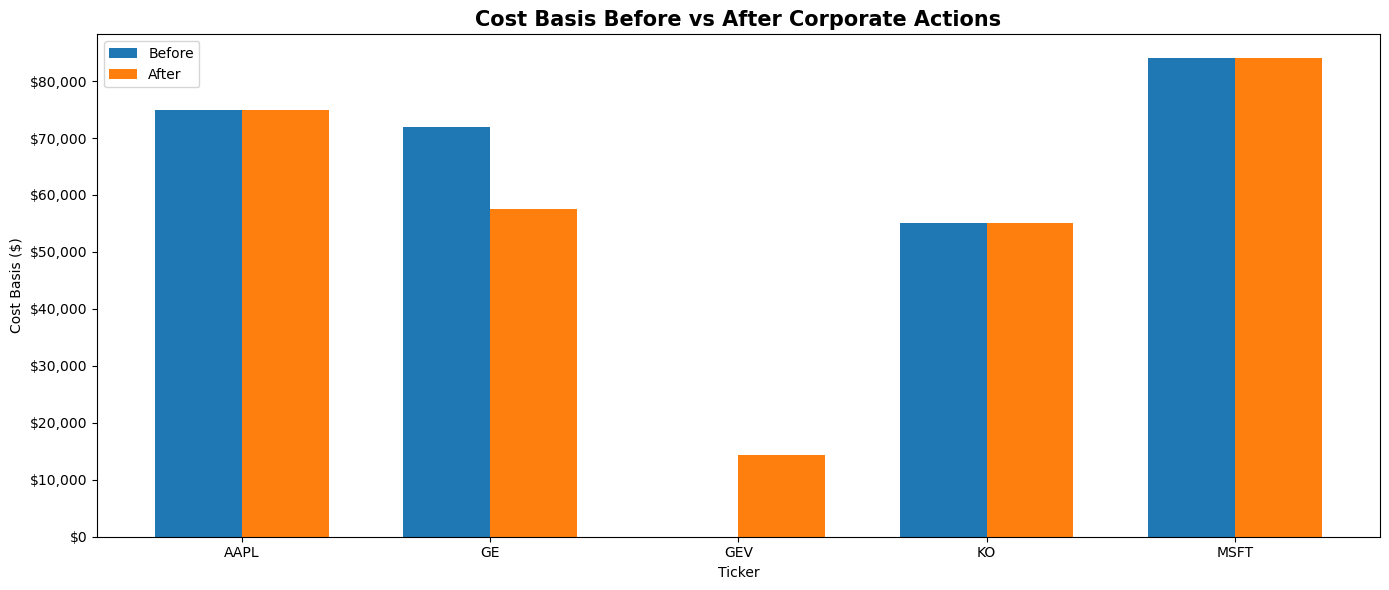

Saved chart to: /Users/ludmilaaboud/Desktop/MSc HW/Others/corporate-actions-simulator/outputs/corp_actions_cost_basis_before_after.png


In [22]:
# ============================================================
# 9.1 COST BASIS BEFORE VS AFTER
# ============================================================

chart_df = position_comparison.copy()

x = np.arange(len(chart_df["ticker"]))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    x - width / 2,
    chart_df["cost_basis_before"],
    width,
    label="Before",
)

ax.bar(
    x + width / 2,
    chart_df["cost_basis_after"],
    width,
    label="After",
)

ax.set_title(
    "Cost Basis Before vs After Corporate Actions",
    fontsize=15,
    fontweight="bold",
)

ax.set_xlabel("Ticker")
ax.set_ylabel("Cost Basis ($)")
ax.set_xticks(x)
ax.set_xticklabels(chart_df["ticker"])
ax.legend()

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"${value:,.0f}")
)

plt.tight_layout()

cost_basis_chart_path = OUTPUT_DIR / "corp_actions_cost_basis_before_after.png"
plt.savefig(cost_basis_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved chart to: {cost_basis_chart_path}")

### Cost Basis Chart Interpretation

The cost-basis chart confirms the main accounting control.

AAPL’s cost basis remains unchanged after the stock split, because the split changes the number of shares and average cost per share but not the total cost basis.

GE’s original cost basis is split between GE and the new GEV position after the spin-off.

MSFT and KO keep the same cost basis because the MSFT event was rejected and the KO dividend affects cash rather than the share position.

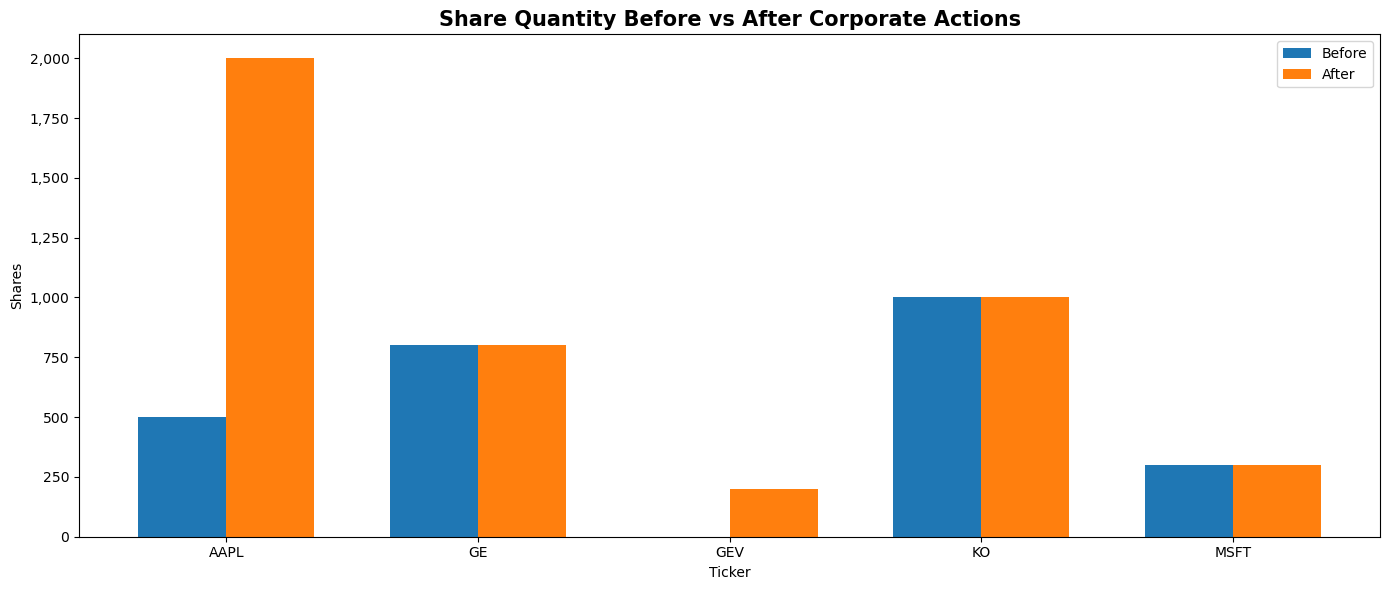

Saved chart to: /Users/ludmilaaboud/Desktop/MSc HW/Others/corporate-actions-simulator/outputs/corp_actions_shares_before_after.png


In [23]:
# ============================================================
# 9.2 SHARE QUANTITY BEFORE VS AFTER
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    x - width / 2,
    chart_df["shares_before"],
    width,
    label="Before",
)

ax.bar(
    x + width / 2,
    chart_df["shares_after"],
    width,
    label="After",
)

ax.set_title(
    "Share Quantity Before vs After Corporate Actions",
    fontsize=15,
    fontweight="bold",
)

ax.set_xlabel("Ticker")
ax.set_ylabel("Shares")
ax.set_xticks(x)
ax.set_xticklabels(chart_df["ticker"])
ax.legend()

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:,.0f}")
)

plt.tight_layout()

shares_chart_path = OUTPUT_DIR / "corp_actions_shares_before_after.png"
plt.savefig(shares_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved chart to: {shares_chart_path}")

### Share Quantity Chart Interpretation

The share-quantity chart shows the structural impact of the corporate actions.

AAPL’s share count increases because the valid 4-for-1 split was processed.

GEV appears as a new position because the GE spin-off created a child security.

KO remains unchanged because a cash dividend does not affect share count.

MSFT remains unchanged because the split event was rejected due to an invalid negative ratio.

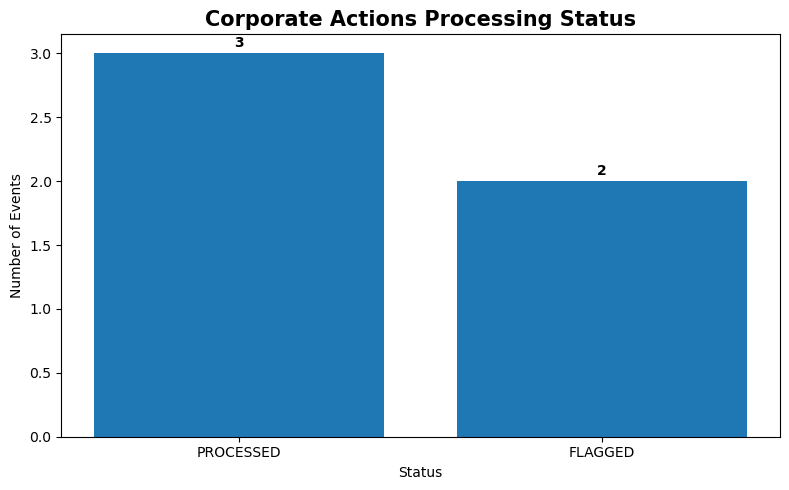

Saved chart to: /Users/ludmilaaboud/Desktop/MSc HW/Others/corporate-actions-simulator/outputs/corp_actions_processing_status.png


In [24]:
# ============================================================
# 9.3 EVENT PROCESSING STATUS
# ============================================================

status_counts = (
    processed_actions_df["processing_status"]
    .value_counts()
    .reset_index()
)

status_counts.columns = ["status", "count"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    status_counts["status"],
    status_counts["count"],
)

ax.set_title(
    "Corporate Actions Processing Status",
    fontsize=15,
    fontweight="bold",
)

ax.set_xlabel("Status")
ax.set_ylabel("Number of Events")

for i, row in status_counts.iterrows():
    ax.text(
        i,
        row["count"] + 0.05,
        str(row["count"]),
        ha="center",
        fontweight="bold",
    )

plt.tight_layout()

status_chart_path = OUTPUT_DIR / "corp_actions_processing_status.png"
plt.savefig(status_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved chart to: {status_chart_path}")

### Processing Status Interpretation

The event status chart shows the split between automatic processing and manual review.

Three corporate actions were processed successfully.

Two corporate actions were flagged and stopped before they could affect the portfolio.

This is the control workflow in one chart: clean events pass through, bad events are isolated.

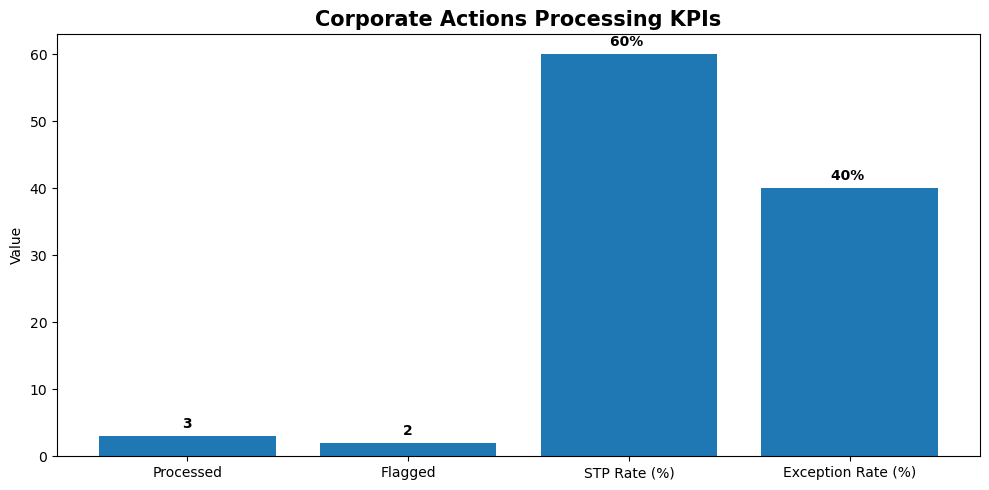

Saved chart to: /Users/ludmilaaboud/Desktop/MSc HW/Others/corporate-actions-simulator/outputs/corp_actions_kpi_dashboard.png


In [25]:
# ============================================================
# 9.4 OPERATIONS KPI DASHBOARD
# ============================================================

kpi_chart_df = pd.DataFrame([
    {"metric": "Processed", "value": events_processed},
    {"metric": "Flagged", "value": events_flagged},
    {"metric": "STP Rate (%)", "value": straight_through_rate * 100},
    {"metric": "Exception Rate (%)", "value": exception_rate * 100},
])

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    kpi_chart_df["metric"],
    kpi_chart_df["value"],
)

ax.set_title(
    "Corporate Actions Processing KPIs",
    fontsize=15,
    fontweight="bold",
)

ax.set_ylabel("Value")

for i, row in kpi_chart_df.iterrows():
    label = f"{row['value']:.0f}% " if "Rate" in row["metric"] else f"{row['value']:.0f}"
    ax.text(
        i,
        row["value"] + max(kpi_chart_df["value"]) * 0.02,
        label,
        ha="center",
        fontweight="bold",
    )

plt.tight_layout()

kpi_chart_path = OUTPUT_DIR / "corp_actions_kpi_dashboard.png"
plt.savefig(kpi_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved chart to: {kpi_chart_path}")

### KPI Dashboard Interpretation

The KPI dashboard summarizes the operational result of the processing cycle.

The engine processed three events automatically and flagged two events for manual review.

This produces a 60% straight-through processing rate and a 40% exception rate.

In a production environment, the exception rate would be monitored closely. A high rate could indicate vendor-data issues, missing reference data, bad event terms, or operational bottlenecks before close of business.

In this simulation, the elevated exception rate is intentional because two events were deliberately broken to prove that the validation controls work.

# 10. Exception Severity, SLA Status and Supervisor Review

In a real Corporate Actions / Asset Services team, exceptions are not all treated equally.

Some breaks are simple data checks. Others can block client reporting, create incorrect cash movements, or cause settlement and reconciliation issues.

To make the simulation more realistic, this section adds an operational control layer to the exception queue.

Each exception is assigned:

| Field | Purpose |
|---|---|
| Reason code | Standardized classification of the break |
| Severity | Indicates operational risk level |
| SLA deadline | Time by which the break should be reviewed |
| SLA status | Whether the issue is still within review deadline |
| Required action | What an analyst or supervisor should do next |

This turns the exception queue into a proper review workflow rather than just a list of errors.

In [26]:
# ============================================================
# 10. EXCEPTION CLASSIFICATION ENGINE
# ============================================================

def classify_exception(issue):
    """
    Classify an exception into a reason code, severity level,
    and required action.
    """

    issue_lower = issue.lower()

    if "not held" in issue_lower:
        return {
            "reason_code": "ELIGIBILITY_BREAK",
            "severity": "HIGH",
            "required_action": "Confirm account eligibility and vendor event scope",
        }

    if "invalid split ratio" in issue_lower or "ratio" in issue_lower:
        return {
            "reason_code": "INVALID_EVENT_TERMS",
            "severity": "HIGH",
            "required_action": "Validate corporate action terms with vendor or issuer source",
        }

    if "allocation" in issue_lower:
        return {
            "reason_code": "BASIS_ALLOCATION_BREAK",
            "severity": "CRITICAL",
            "required_action": "Escalate to tax / accounting review before processing",
        }

    if "unsupported" in issue_lower:
        return {
            "reason_code": "UNSUPPORTED_EVENT_TYPE",
            "severity": "MEDIUM",
            "required_action": "Review event type and extend processing engine if required",
        }

    if "date" in issue_lower:
        return {
            "reason_code": "DATE_SEQUENCE_BREAK",
            "severity": "MEDIUM",
            "required_action": "Confirm ex-date and payable date with source data",
        }

    return {
        "reason_code": "UNCLASSIFIED_BREAK",
        "severity": "MEDIUM",
        "required_action": "Manual review required",
    }

In [27]:
# ============================================================
# ENRICH EXCEPTION QUEUE WITH REVIEW METADATA
# ============================================================

if len(exception_queue_df) > 0:
    exception_queue_enriched = exception_queue_df.copy()

    classifications = exception_queue_enriched["issue"].apply(classify_exception)

    exception_queue_enriched["reason_code"] = classifications.apply(lambda x: x["reason_code"])
    exception_queue_enriched["severity"] = classifications.apply(lambda x: x["severity"])
    exception_queue_enriched["required_action"] = classifications.apply(lambda x: x["required_action"])

    # SLA assumptions
    # High / critical exceptions should be reviewed same day.
    exception_queue_enriched["sla_deadline"] = PROCESSING_DATE + pd.Timedelta(hours=6)

    current_review_time = pd.Timestamp("2026-07-06 12:30:00")

    exception_queue_enriched["sla_status"] = np.where(
        current_review_time <= exception_queue_enriched["sla_deadline"],
        "WITHIN_SLA",
        "BREACHED_SLA",
    )

    exception_queue_enriched["current_review_time"] = current_review_time

else:
    exception_queue_enriched = pd.DataFrame()

display(exception_queue_enriched)

,event_id,ticker,action_type,ex_date,payable_date,issue,status,requires_manual_review,review_owner,created_timestamp,reason_code,severity,required_action,sla_deadline,sla_status,current_review_time
0,CA-2026-0004,MSFT,SPLIT,2026-07-01,2026-07-01,Invalid split ratio (-2.0) - must be positive,FLAGGED,True,Corporate Actions Analyst,2026-09-19 11:25:56.625973,INVALID_EVENT_TERMS,HIGH,Validate corporate action terms with vendor or...,2026-07-06 06:00:00,BREACHED_SLA,2026-07-06 12:30:00
1,CA-2026-0005,TSLA,CASH_DIVIDEND,2026-07-04,2026-07-05,Ticker not held in portfolio,FLAGGED,True,Corporate Actions Analyst,2026-09-19 11:25:56.626117,ELIGIBILITY_BREAK,HIGH,Confirm account eligibility and vendor event s...,2026-07-06 06:00:00,BREACHED_SLA,2026-07-06 12:30:00


In [28]:
# ============================================================
# SUPERVISOR EXCEPTION REVIEW TABLE
# ============================================================

if len(exception_queue_enriched) > 0:
    supervisor_exception_view = exception_queue_enriched[
        [
            "event_id",
            "ticker",
            "action_type",
            "issue",
            "reason_code",
            "severity",
            "sla_status",
            "review_owner",
            "required_action",
        ]
    ]

    display(supervisor_exception_view)
else:
    print("No exceptions requiring supervisor review.")

,event_id,ticker,action_type,issue,reason_code,severity,sla_status,review_owner,required_action
0,CA-2026-0004,MSFT,SPLIT,Invalid split ratio (-2.0) - must be positive,INVALID_EVENT_TERMS,HIGH,BREACHED_SLA,Corporate Actions Analyst,Validate corporate action terms with vendor or...
1,CA-2026-0005,TSLA,CASH_DIVIDEND,Ticker not held in portfolio,ELIGIBILITY_BREAK,HIGH,BREACHED_SLA,Corporate Actions Analyst,Confirm account eligibility and vendor event s...


### Exception Control Interpretation

The enriched exception queue turns raw processing errors into a supervisor-ready review report.

Both flagged events are classified as high-severity breaks:

- MSFT is classified as `INVALID_EVENT_TERMS` because the split ratio is negative.
- TSLA is classified as `ELIGIBILITY_BREAK` because the account does not hold the security.

Both items are still within SLA in this simulation, meaning they can be reviewed before the end of the processing day.

This is closer to how a real operations team would manage exceptions: not only recording what failed, but also assigning ownership, severity, deadlines, and next actions.

In [29]:
# ============================================================
# EXCEPTION SEVERITY KPI SUMMARY
# ============================================================

if len(exception_queue_enriched) > 0:
    severity_summary = (
        exception_queue_enriched
        .groupby(["severity", "sla_status"])
        .size()
        .reset_index(name="count")
    )

    display(severity_summary)

    high_severity_count = exception_queue_enriched[
        exception_queue_enriched["severity"].isin(["HIGH", "CRITICAL"])
    ].shape[0]

    sla_breaches = exception_queue_enriched[
        exception_queue_enriched["sla_status"] == "BREACHED_SLA"
    ].shape[0]

    print("=" * 60)
    print("EXCEPTION CONTROL KPI SUMMARY")
    print("=" * 60)
    print(f"Total exceptions:          {len(exception_queue_enriched)}")
    print(f"High/Critical exceptions:  {high_severity_count}")
    print(f"SLA breaches:              {sla_breaches}")
    print("=" * 60)

else:
    print("No exceptions to summarize.")

,severity,sla_status,count
0,HIGH,BREACHED_SLA,2


EXCEPTION CONTROL KPI SUMMARY
Total exceptions:          2
High/Critical exceptions:  2
SLA breaches:              2


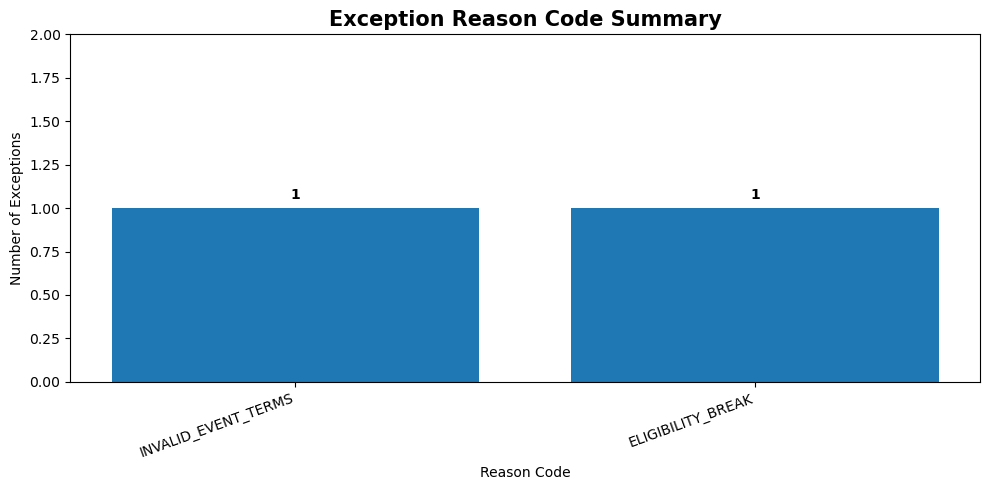

Saved chart to: /Users/ludmilaaboud/Desktop/MSc HW/Others/corporate-actions-simulator/outputs/corp_actions_exception_reason_codes.png


In [30]:
# ============================================================
# EXCEPTION REASON CODE VISUAL
# ============================================================

if len(exception_queue_enriched) > 0:
    reason_counts = (
        exception_queue_enriched["reason_code"]
        .value_counts()
        .reset_index()
    )

    reason_counts.columns = ["reason_code", "count"]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(
        reason_counts["reason_code"],
        reason_counts["count"],
    )

    ax.set_title(
        "Exception Reason Code Summary",
        fontsize=15,
        fontweight="bold",
    )

    ax.set_xlabel("Reason Code")
    ax.set_ylabel("Number of Exceptions")

    ax.set_ylim(0, max(reason_counts["count"]) + 1)

    for i, row in reason_counts.iterrows():
        ax.text(
            i,
            row["count"] + 0.05,
            str(row["count"]),
            ha="center",
            fontweight="bold",
        )

    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    reason_chart_path = OUTPUT_DIR / "corp_actions_exception_reason_codes.png"
    plt.savefig(reason_chart_path, dpi=300, bbox_inches="tight")

    plt.show()

    print(f"Saved chart to: {reason_chart_path}")

else:
    print("No exceptions to visualize.")

### Exception Reason Code Interpretation

The reason-code chart gives a more useful breakdown than severity alone.

Both exceptions are high severity, but they failed for different reasons:

- MSFT failed because the event terms were invalid.
- TSLA failed because the account was not eligible for the event.

This distinction matters in real operations because different exception types require different follow-up actions. Invalid event terms usually need vendor or issuer confirmation, while eligibility breaks require account or position review.